# Operaciones sobre arreglos

In [31]:
!rm -fr sample_data
!git clone https://github.com/jmbajo/diplodatos-demo-imgs.git
!mv diplodatos-demo-imgs/* .
!rm -rf diplodatos-demo-imgs

Cloning into 'diplodatos-demo-imgs'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 6.27 MiB | 11.93 MiB/s, done.
Resolving deltas: 100% (3/3), done.


Veamos cuál es la ventaja de trabajar de forma "vectorizada" con los arreglos (o matrices)

In [32]:
import numpy as np
rng = np.random.default_rng(seed=1701)

# Esta función computa 1/N para cada valor de una secuencia
def compute_reciprocals(values):
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0 / values[i]
    return output

values = rng.integers(1, 10, size=5)

print(values)
print(compute_reciprocals(values))

[9 4 1 3 8]
[0.11111111 0.25       1.         0.33333333 0.125     ]


Típicamente, las librerías de matrices y vectores nos permiten hacer esto:

In [33]:
1 / values

array([0.11111111, 0.25      , 1.        , 0.33333333, 0.125     ])

¿Qué diferencia habrá entre hacerlo de una forma u otra?

In [34]:
big_array = rng.integers(1, 100, size=1000000)
%timeit compute_reciprocals(big_array)

1.63 s ± 188 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [35]:
%timeit (1.0 / big_array)

1.41 ms ± 178 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Operaciones Vectorizadas

In [ ]:
x = np.arange(4)
print("x      =", x)
print("x + 5  =", x + 5)
print("x - 5  =", x - 5)
print("x * 2  =", x * 2)
print("x / 2  =", x / 2)
print("x // 2 =", x // 2)  # division entera
print("-x     = ", -x)
print("x ** 2 = ", x ** 2)
print("x % 2  = ", x % 2)

In [ ]:
-(0.5*x + 1) ** 2

In [ ]:
# Además de los operadores, también están definidas como funciones.
np.add(x, 2)

In [ ]:
# exponenciales y logarítmicas

x = [1, 2, 3]
print("x   =", x)
print("e^x =", np.exp(x))
print("2^x =", np.exp2(x))
print("3^x =", np.power(3., x))

x = [1, 2, 4, 10]
print("x        =", x)
print("ln(x)    =", np.log(x))
print("log2(x)  =", np.log2(x))
print("log10(x) =", np.log10(x))

## Operaciones de reducción

In [ ]:
x = np.arange(1, 6)
np.sum(x)

In [ ]:
x

In [ ]:
print(np.min(big_array))
print(np.max(big_array))

Están definidas como métodos de la clase ndarray.

In [ ]:
print(big_array.min(), big_array.max(), big_array.sum())

## Reducciones por dimensión

In [ ]:
M = rng.integers(0, 10, (3, 4))
print(M)

Por defecto, las operaciones de reducción trabajarán sobre todos los elementos del arreglo.

In [ ]:
M.sum()

Las funciones de agregación, toman un parámtro opcional para especificar sobre que dimensión hacer la reducción.

In [ ]:
M.min(axis=0)

La operación retorna un arreglo de una dimensión con los resultados

De la misma manera, podemos calcular el maximo en cada fila:

In [ ]:
M.max(axis=1)

The following table provides a list of useful aggregation functions available in NumPy:

|Función    |   Versión Nan-Safe| Descripción                                   |
|-----------------|-------------------|-----------------------------------------------|
| `np.sum`        | `np.nansum`       | Compute sum of elements                       |
| `np.prod`       | `np.nanprod`      | Compute product of elements                   |
| `np.mean`       | `np.nanmean`      | Compute mean of elements                      |
| `np.std`        | `np.nanstd`       | Compute standard deviation                    |
| `np.var`        | `np.nanvar`       | Compute variance                              |
| `np.min`        | `np.nanmin`       | Find minimum value                            |
| `np.max`        | `np.nanmax`       | Find maximum value                            |
| `np.argmin`     | `np.nanargmin`    | Find index of minimum value                   |
| `np.argmax`     | `np.nanargmax`    | Find index of maximum value                   |
| `np.median`     | `np.nanmedian`    | Compute median of elements                    |
| `np.percentile` | `np.nanpercentile`| Compute rank-based statistics of elements     |
| `np.any`        | N/A               | Evaluate whether any elements are true        |
| `np.all`        | N/A               | Evaluate whether all elements are true        |

<font color='#ff4d00'>Ejercicio: Una forma elemental de convertir una imagen RGB en escala de grises es promediar los valores de R,G,B de cada pixel. Implementar este método. </font>

(250, 250)
1.0 251.66666666666666


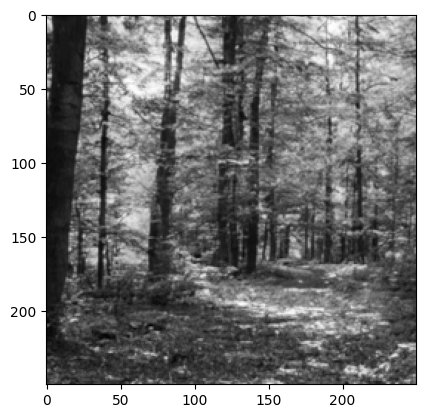

In [40]:
import imageio.v3 as iio

im = iio.imread('woods.png')
imRGB = im[:, :, :3]

imG = imRGB.mean(axis=2)

print(imG.shape)
plt.imshow(imG, "gray")

print(imG.min(), imG.max())



<font color='#ff4d00'>Ejercicio: Dada una imagen en escala de grises, detectar el scanline con mayor intensidad promedio </font>

<font color='#ff4d00'>Ejercicio: Calcular el valor minimo y máximo de la imagen rose_dark.png. Interpretar los resultados </font>



## Operaciones lógicas y máscaras

Asi como vimos operaciones aritméticas vectorizadas, también tenemos implementados de esta manera a los operadores lógicos

In [41]:
x = np.array([1, 2, 3, 4, 5])

print(x < 3)
print(x > 3)
print(x >= 3)
print(x != 3)
print(x == 3)

[ True  True False False False]
[False False False  True  True]
[False False  True  True  True]
[ True  True False  True  True]
[False False  True False False]


In [42]:
rng = np.random.default_rng(seed=1701)
x = rng.integers(10, size=(3, 4)) - 5
x

array([[ 4, -1, -5, -2],
       [ 3,  1, -2, -4],
       [-2,  2, -1, -5]])

In [ ]:
x < 0

Si queremos saber si todos, o algunos, de los valores son True podemos usar:


In [ ]:
np.any(x > 8)

In [ ]:
np.all(x < 10)

## Arreglos lógicos como máscaras



In [43]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
import plotly.express as px

img = iio.imread('cells.png')
px.imshow(img)

A partir de los colores de los pixeles podemos determinar de forma sencilla si este corresponde a una figura (célula) o fondo.

Este proceso se denomina "segmentación" y existen un gran número de técnicas para realizarlo.

<font color='#ff4d00'>Ejercicio: Pensar un criterio a partir del color del pixel y generar una máscara donde los pixeles correspondientes a la figura sean blancos (Verdaderos) y los del fondo negros (Falsos)</font>

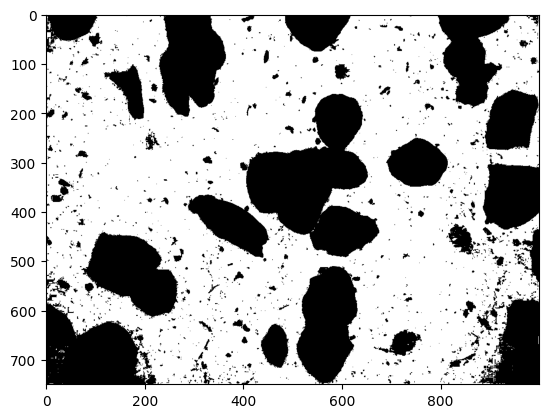

In [46]:
img = iio.imread('cells.png')
px.imshow(img)

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

img_segm = (R > 230) & (G > 230) & (B > 230)

plt.imshow(img_segm, 'gray')

### Observación: Tener cuidado al usar los operadores lógicos del lenguaje

In [ ]:
bool(42), bool(0)

In [ ]:
bool([]), bool([2])

In [ ]:
bool(42 and 0)

In [ ]:
bool(42 or 0)

In [47]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B

array([ True,  True,  True, False,  True,  True])

In [48]:
A or B

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [49]:
bool(A)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Lo que está sucediendo es que al utilizar los operadores lógicos del lenguaje, el intérprete trata de computar un valor de verdad a partir de un arreglo de numpy.
En general, lo que nosotros queremos es computar la operación entre los elementos de 2 arreglos. Recuerden que para operaciones lógicas de reducción tenemos any() y all().

<font color='#ff4d00'>Ejercicio: implementar una expresión que compute si existe un pixel blanco (255, 255, 255) en una imagen</font>

<font color='#ff4d00'>Ejercicio: Buscar una imagen con un color de fondo constante y combinarla con otra</font>

Ayuda: Existe un operación where

`c = np.where(mask, a, b)`

donde c[i,j] = a[i,j] si mask[i,j] es Verdadero, caso contrario b[i,j]
